WALMART WEEKLY SALES PREDICTION USING MACHINE LEARNING

Step 1 - Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Pandas and Numpy are used for data handling and numerical operations , whereas Matplotlib and Seaborn are used for data visulization

Step 2 - Load Dataset

In [2]:
df=pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


The Walmart dataset is loaded using Pandas.The first five rows are displayed to understand the dataset.

Step 3 - Understand Dataset

In [3]:
print(df.shape)
print(df.columns)
df.info()
print(df.describe())

(6435, 8)
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.64

We check the size,columns,data types,and statistical summary.This helps us understand the structure and basic characteristics of the dataset

Step 4 - Check Missing Values

In [4]:
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


We check each column for missing values.
Missing values are handled if they are present.

Step 5 - Check Duplicates

In [5]:
print(df.duplicated().sum())

0


We check for duplicate rows in the dataset.Duplicates records can affect the model,so they are identified before training.

Step 6 - Convert Date

In [6]:
df["Date"]=pd.to_datetime(df["Date"],format="%d-%m-%Y")
print(df.dtypes)

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


The Date column is converted into datetime format using the correct day-month-year format.This allows us to extract useful time-based features such as Year,Month,Week,and Quarter.

Step 7 - Feature Engineering


In [7]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Week"]=df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"]=df["Date"].dt.quarter


We extract Year,Month,Week,and Quarter from the Date column.These features help the model learn time-based and seasonal sales patterns.

In [8]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


Step 8 - Weekly Sales Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

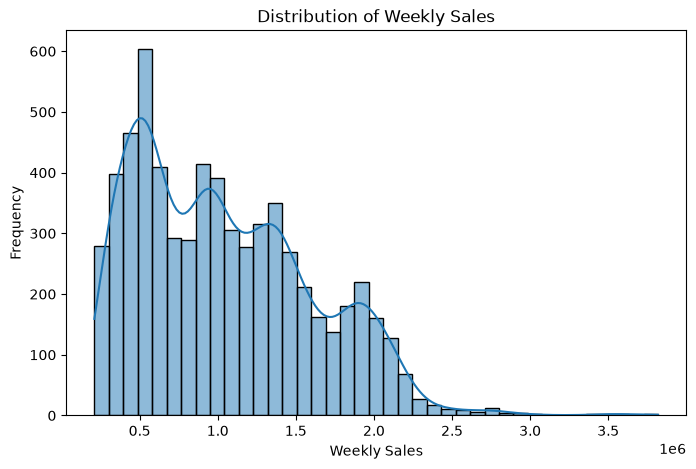

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Weekly_Sales"],kde=True)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show

We visualize the distribution of Weekly Sales using a histogram.This helps us understand the spread and overall pattern of the target variable.

Step 9 - Average Weekly Sales by Store

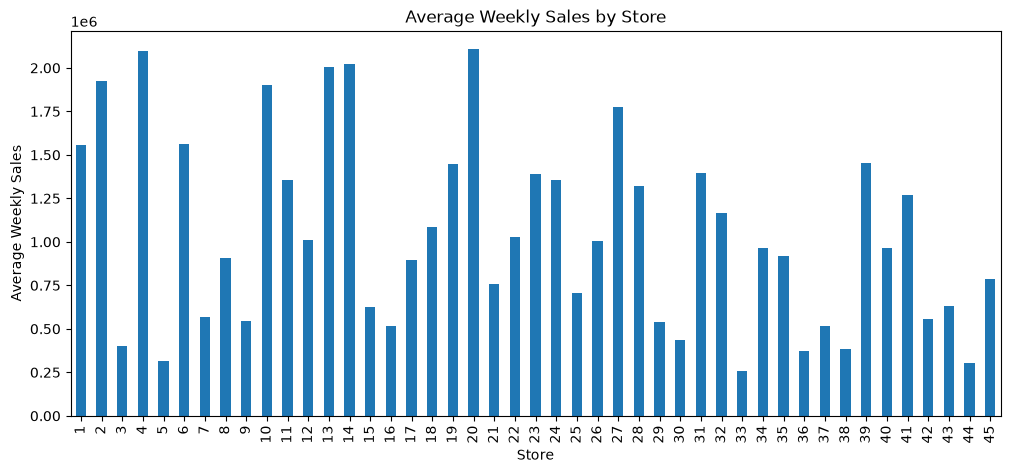

In [10]:
store_sales=df.groupby("Store")["Weekly_Sales"].mean()
plt.figure(figsize=(12,5))
store_sales.plot(kind="bar")
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

We calculate the average Weekly Sales for each store. This helps us compare the sales performance of different stores.

STEP 10 - Holiday vs Non-Holiday Sales

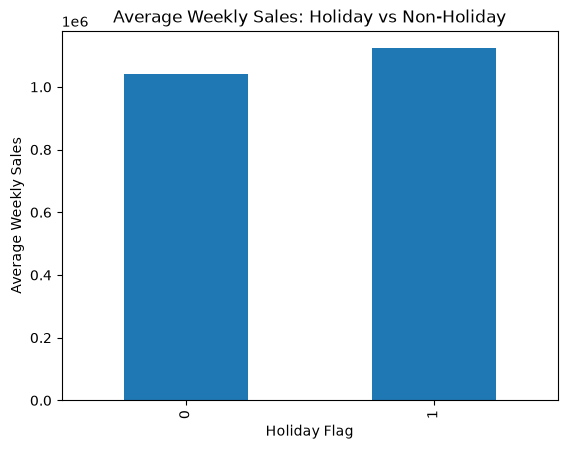

In [11]:
holiday_sales=df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
holiday_sales.plot(kind="bar")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.show()


We compare the average sales of holiday and non-holiday weeks.This helps us understand the effect of holidays on weekly sales, whether holidays are associated with changes in sales.
Holiday_Flag:                                                                                                                              
o -> Non-Holiday                                                                                                                           
1 -> Holiday



Step 11- Year-Wise Sales Analysis

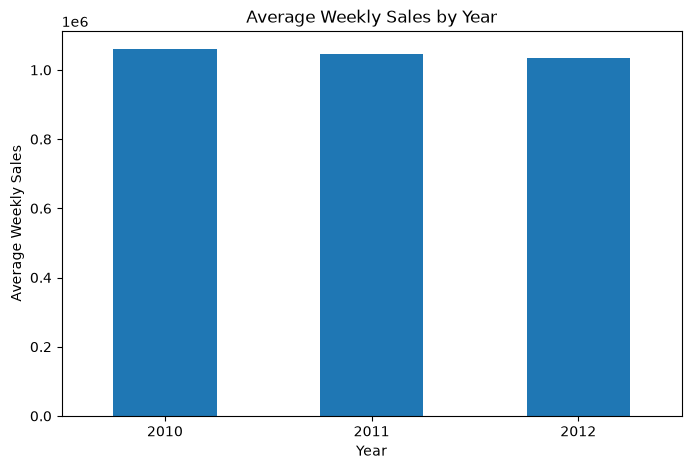

In [12]:
year_sales=df.groupby("Year")["Weekly_Sales"].mean()
plt.figure(figsize=(8,5))
year_sales.plot(kind="bar")
plt.title("Average Weekly Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.show()

We calculate the average weekly sales for each year. This helps us identify changes in sales across different years.

Step 12 - Month-Wise Sales Analysis

Month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64


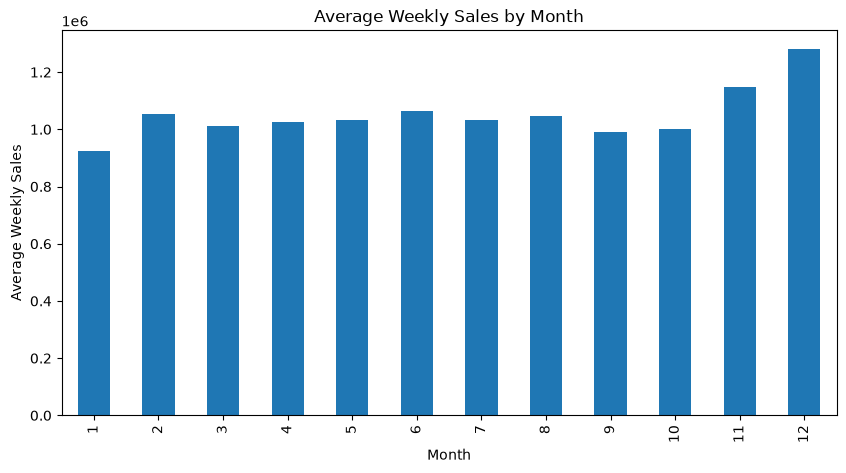

In [13]:
month_sales=df.groupby("Month")["Weekly_Sales"].mean()
plt.figure(figsize=(10,5))
print(month_sales)
month_sales.plot(kind="bar")
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

We calculate the average weekly sales for each month.This helps us to identify possible monthly sales patterns.

Step 13- Feature Relationship Analysis

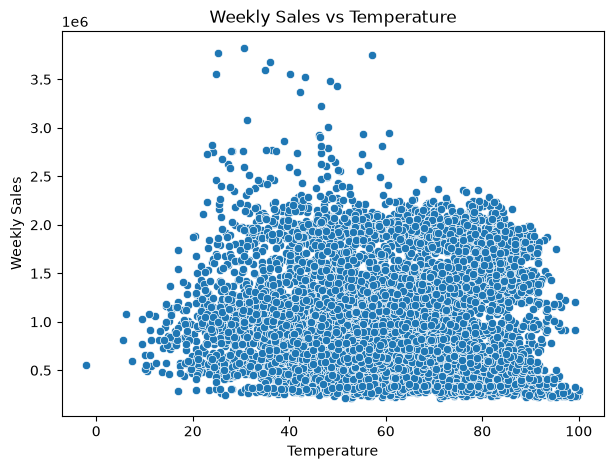

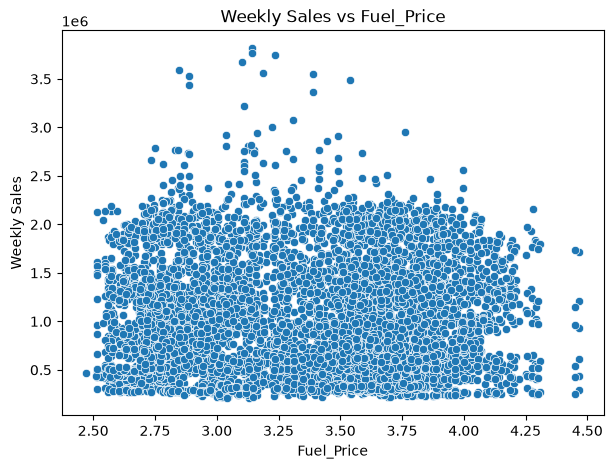

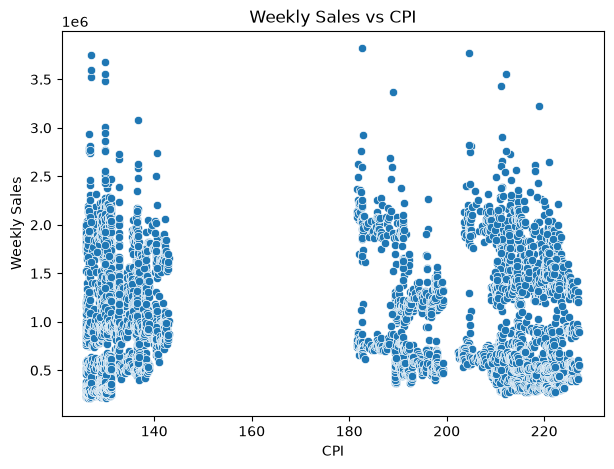

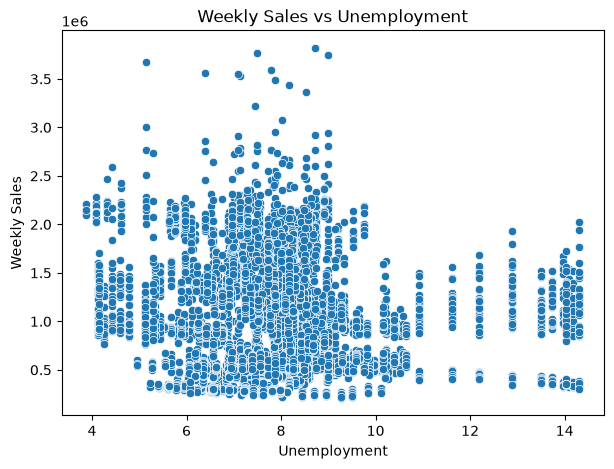

In [14]:
features=["Temperature","Fuel_Price","CPI","Unemployment"]
for feature in features:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=df[feature],y=df["Weekly_Sales"])
    plt.title(f"Weekly Sales vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Weekly Sales")
    plt.show()


We visualize the relationship between weekly Sales and important numerical features.Scatter plots help us observe possible relationships and patterns.

Step 14 - Correlation Analysis + Heatmap

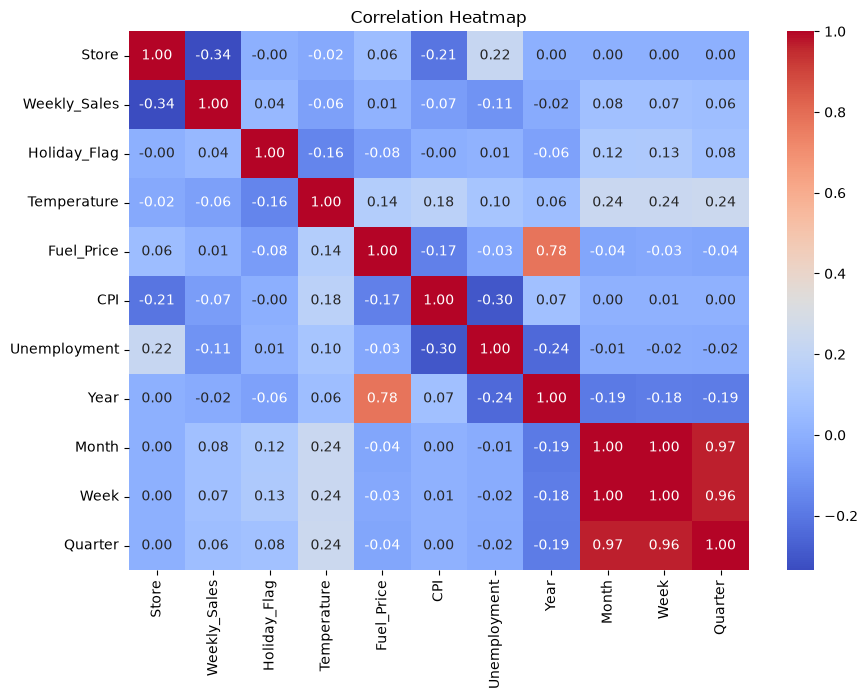

In [15]:
correlation=df.corr(numeric_only=True)
correlation["Weekly_Sales"].sort_values(ascending=False)
plt.figure(figsize=(10,7))
sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

We calculate correlations between the numerical features. The heatmap makes strong and weak relationships easier to identify. This helps us understand which features are related to weekly sales.

Step 15 - Outlier Analysis


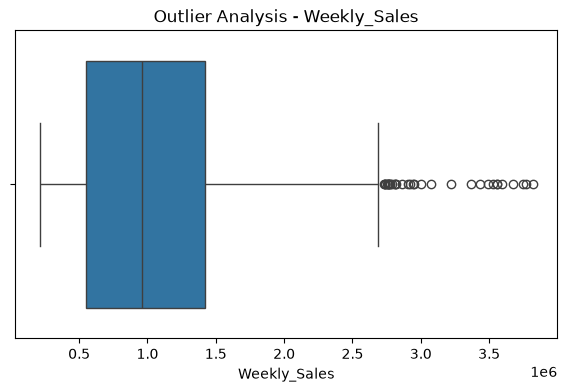

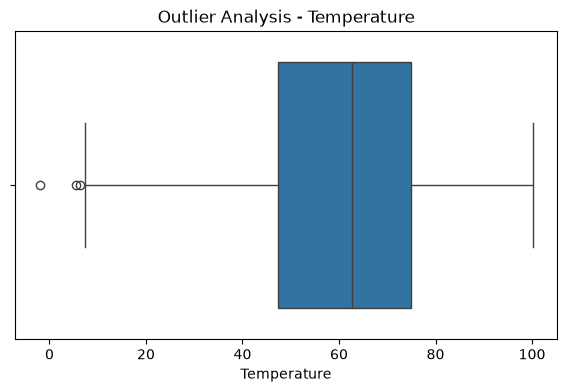

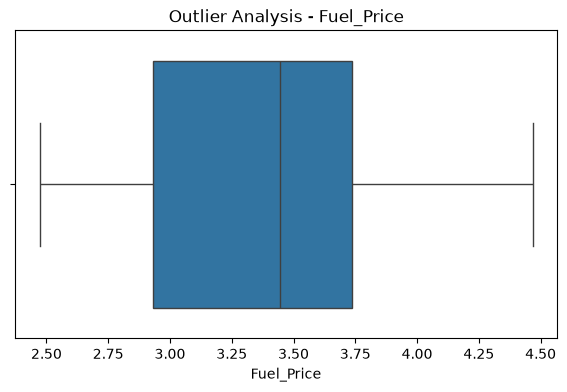

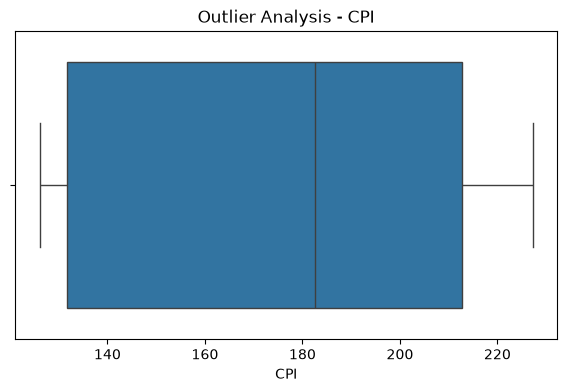

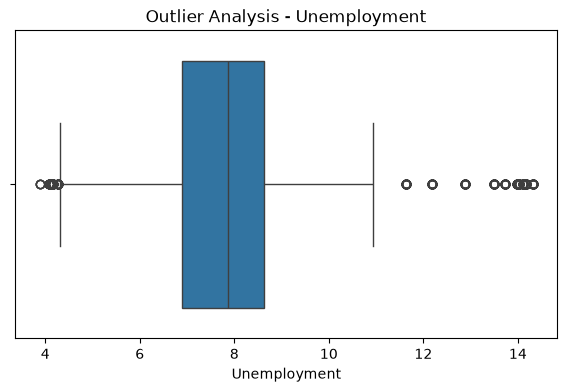

In [16]:
numeric_columns=[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]
for column in numeric_columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[column])
    plt.title(f"Outlier Analysis - {column}")
    plt.show()


Boxplots are used to identify possible outliers in numerical features.This helps us understand unusual values before model training.
We retain the data because extreme sales values can represent genuine store sales rather than errors.

p-value Analysis

In [59]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/11.3 MB 2.2 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.3 MB 1.2 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.3 MB 1.6 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/11.3 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.4/11.3 MB 1.8 MB/s eta 0:00:05
   --------- ------------------------------ 2.6/11.3 MB 1.6 MB/s eta 0:00:06
   ----------- ---------------------------- 3.1/11.3 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.4/11.3 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.4/11.3 MB 1.7 MB/s eta 0:00:05
   -------------- --


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import statsmodels.api as sm
X_p=df[["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Year","Month","Week","Quarter"]].copy()
y_p=df["Weekly_Sales"]
X_p=sm.add_constant(X_p)
ols_model=sm.OLS(y_p,X_p).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     114.0
Date:                Tue, 01 Sep 2026   Prob (F-statistic):          3.18e-219
Time:                        09:50:24   Log-Likelihood:                -93826.
No. Observations:                6435   AIC:                         1.877e+05
Df Residuals:                    6424   BIC:                         1.877e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.874e+07   3.02e+07      1.946      0.052   -4.27e+05    1.18e+08
Store        -1.538e+04    519.810    -29.583      0.000   -1.64e+04   -1.44e+04
Holiday_Flag  3.544e+04   2.65e+04      1.336      0.182   -1.66e+04    8.74e+04
Temperature  -1739.2091    390.628     -4.452      0.000   -2504.969    -973.449
Fuel_Price    5.974e+04   2.56e+04      2.336      0.020    9601.166     1.1e+05
CPI          -2124.0638    191.630    -11.084      0.000   -2499.722   -1748.406
Unemployment -2.244e+04   3928.926     -5.711      0.000   -3.01e+04   -1.47e+04
Year         -2.833e+04    1.5e+04     -1.884      0.060   -5.78e+04    1155.424
Month         7.218e+04   2.37e+04      3.046      0.002    2.57e+04    1.19e+05
Week         -8065.4148   5191.692     -1.554      0.120   -1.82e+04    2112.032
Quarter      -7.167e+04   2.42e+04     -2.965      0.003   -1.19e+05   -2.43e+04
==============================================================================
Omnibus:                      146.817   Durbin-Watson:                   0.134
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              156.330
Skew:                           0.379   Prob(JB):                     1.13e-34
Kurtosis:                       2.910   Cond. No.                     9.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

OLS regression was performed to evaluate the statistical significance of the selected features using their p-values. The regression summary also provides R², adjusted R², coefficients, t-statistics, and overall model significance.

Step 15A- R² Score and P-value

In [61]:
r2_ols=ols_model.rsquared
p_value_ols=ols_model.f_pvalue
print("R² Score:",r2_ols)
print("Overall P-value:",p_value_ols)

R² Score: 0.1507034419138341
Overall P-value: 3.1802749237350937e-219


The OLS model was further evaluated using R² and the overall p-value. R² measures how much variation in Weekly Sales is explained by the model, while the p-value indicates the statistical significance of the overall regression model.

Step 16 - Define Features and Target

In [34]:
features=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Year","Month","Week","Quarter"]
X=df[features].copy()
y=df["Weekly_Sales"].copy()
X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,0,46.50,2.625,211.350143,8.106,2010,3,9,1


The Date column was removed because it contains datetime values that cannot be directly used by the regression models.
The extracted Year, Month, Week and Quarter features were retained, while Weekly_Sales was assigned to y as the target variable to be predicted.

Step 17 - Train-Test Split

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
X_train.shape,X_test.shape

((5148, 10), (1287, 10))

After seperating the features and target,we split the dataset into training and testing data.80% of the data is used for training and 20% for testing.The testing data helps us evaluate the model on unseen data.

Step 18 - Linear Regression 

In [37]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
y_pred_lr=lr_model.predict(X_test)
print("Linear Regression trained successfully")

Linear Regression trained successfully


After splitting the data,we now build our first machine learning model.Linear Regression is trained using the training data.The trained model is used to predict weekly sales on the test data.MSE,MAE,RMSE,and R^2 Score are used to evaluate the model.

Step 19 - Linear Regression Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae_lr=mean_absolute_error(y_test,y_pred_lr)
mse_lr=mean_squared_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mse_lr)
r2_lr=r2_score(y_test,y_pred_lr)
print("MAE:",mae_lr)
print("MSE:",mse_lr)
print("RMSE:",rmse_lr)
print("R2 Score:",r2_lr)

MAE: 433270.43422742333
MSE: 272330846318.5776
RMSE: 521853.28045206115
R2 Score: 0.15465780648429317


The Linear Regression model was evaluated using MAE,MSE,RMSE and R² Score.
These metrics were used to measure prediction error and determine how well the model explains Weekly_Sales.

Step 20- Ridge Regression

In [40]:
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=1.0)
ridge_model.fit(X_train,y_train)
y_pred_ridge=ridge_model.predict(X_test)
print("Ridge Regression trained successfully")

Ridge Regression trained successfully


Ridge Regression was trained using L2 regularization to control large model coefficients.
The trained model was used to predict Weekly_Sales on the test data.

Step 21- Ridge Regression Evaluation

In [41]:
mae_ridge=mean_absolute_error(y_test,y_pred_ridge)
mse_ridge=mean_squared_error(y_test,y_pred_ridge)
rmse_ridge=np.sqrt(mse_ridge)
r2_ridge=r2_score(y_test,y_pred_ridge)
print("MAE:",mae_ridge)
print("MSE:",mse_ridge)
print("RMSE:",rmse_ridge)
print("R2 Score:",r2_ridge)

MAE: 433266.80443803035
MSE: 272327942481.7105
RMSE: 521850.4982096985
R2 Score: 0.15466682028445577


The Ridge Regression model was evaluated using MAE,MSE,RMSE and R² Score.
These metrics were used to measure prediction error and determine the model's performance.

Step 22 - Lasso Regression

In [42]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=1.0,max_iter=10000)
lasso_model.fit(X_train,y_train)
y_pred_lasso=lasso_model.predict(X_test)
print("Lasso Regression trained successfully")

Lasso Regression trained successfully


Lasso Regression was trained using L1 regularization to reduce less important feature coefficients.
The trained model was used to predict Weekly_Sales on the test data.

Step 23 - Lasso Regression Evaluation

In [43]:
mae_lasso=mean_absolute_error(y_test,y_pred_lasso)
mse_lasso=mean_squared_error(y_test,y_pred_lasso)
rmse_lasso=np.sqrt(mse_lasso)
r2_lasso=r2_score(y_test,y_pred_lasso)
print("MAE:",mae_lasso)
print("MSE:",mse_lasso)
print("RMSE:",rmse_lasso)
print("R2 Score:",r2_lasso)

MAE: 433270.3714425929
MSE: 272330900429.65594
RMSE: 521853.3322971656
R2 Score: 0.15465763851809233


The Lasso Regression model was evaluated using MAE,MSE,RMSE and R² Score.
The results were used to understand the prediction accuracy and error of the model.

Step 24- Decision Tree 

In [46]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor(random_state=42,max_depth=10)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)
print("Decision Tree Regression trained successfully")

Decision Tree Regression trained successfully


A Decision Tree Regressor was trained to capture nonlinear relationships in the dataset.
The trained model was used to predict Weekly_Sales on the test data.

Step 25 - Decision Tree Evaluation

In [47]:
mae_dt=mean_absolute_error(y_test,y_pred_dt)
mse_dt=mean_squared_error(y_test,y_pred_dt)
rmse_dt=np.sqrt(mse_dt)
r2_dt=r2_score(y_test,y_pred_dt)
print("MAE:",mae_dt)
print("MSE:",mse_dt)
print("RMSE:",rmse_dt)
print("R2 Score:",r2_dt)

MAE: 73908.71068126519
MSE: 20095733263.011208
RMSE: 141759.42036778794
R2 Score: 0.9376208333851839


The Decision Tree model was evaluated using MAE,MSE,RMSE and R² Score.
These metrics were used to measure the model's prediction performance.

Step 26 - Random Forest Regression

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print("Random Forest Regression trained successfully")

Random Forest Regression trained successfully


A Random Forest Regressor was trained using multiple decision trees to improve prediction performance.
The trained model was used to predict Weekly_Sales on the test data.

Step 27 - Random Forest evaluation

In [49]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print("MAE:",mae_rf)
print("MSE:",mse_rf)
print("RMSE:",rmse_rf)
print("R2 Score:",r2_rf)

MAE: 62106.92853341102
MSE: 13170539565.512072
RMSE: 114762.97122988787
R2 Score: 0.9591173274838243


The Random Forest model was evaluated using MAE,MSE,RMSE and R² Score.
The evaluation results were used to measure its prediction performance.

Step 28 -Gradient Boosting Regression

In [50]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model=GradientBoostingRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
gb_model.fit(X_train,y_train)
y_pred_gb=gb_model.predict(X_test)
print("Gradient Boosting Regression trained successfully")

Gradient Boosting Regression trained successfully


A Gradient Boosting Regressor was trained to improve predictions by learning from previous model errors.
The trained model was used to predict Weekly_Sales on the test data.

Step 29 - Gradient Boosting Evaluation

In [51]:
mae_gb=mean_absolute_error(y_test,y_pred_gb)
mse_gb=mean_squared_error(y_test,y_pred_gb)
rmse_gb=np.sqrt(mse_gb)
r2_gb=r2_score(y_test,y_pred_gb)
print("MAE:",mae_gb)
print("MSE:",mse_gb)
print("RMSE:",rmse_gb)
print("R2 Score:",r2_gb)

MAE: 203330.20682678674
MSE: 69497442907.66124
RMSE: 263623.6766826175
R2 Score: 0.7842729840358622


The Gradient Boosting model was evaluated using MAE,MSE,RMSE and R² Score.
The evaluation results were used to determine its prediction performance.

Step 30 - Compare All Models

In [52]:
results=pd.DataFrame({
"Model":["Linear Regression","Ridge Regression","Lasso Regression","Decision Tree","Random Forest","Gradient Boosting"],
"MAE":[mae_lr,mae_ridge,mae_lasso,mae_dt,mae_rf,mae_gb],
"MSE":[mse_lr,mse_ridge,mse_lasso,mse_dt,mse_rf,mse_gb],
"RMSE":[rmse_lr,rmse_ridge,rmse_lasso,rmse_dt,rmse_rf,rmse_gb],
"R2 Score":[r2_lr,r2_ridge,r2_lasso,r2_dt,r2_rf,r2_gb]
})
results.sort_values("R2 Score",ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
4,Random Forest,62106.928533,1.317054e+10,114762.971230,0.959117
3,Decision Tree,73908.710681,2.009573e+10,141759.420368,0.937621
5,Gradient Boosting,203330.206827,6.949744e+10,263623.676683,0.784273
1,Ridge Regression,433266.804438,2.723279e+11,521850.498210,0.154667
0,Linear Regression,433270.434227,2.723308e+11,521853.280452,0.154658
2,Lasso Regression,433270.371443,2.723309e+11,521853.332297,0.154658


The performance of all developed regression models was compared using MAE,MSE,RMSE and R² Score.
The model with higher R² Score and lower error values was considered better for prediction.

Step 31 - Best Model Selection

In [ ]:
best_model_name=results_sorted.iloc[0]["Model"]
print("Best Model:",best_model_name)

Best Model: Random Forest


After comparing all models, we select the model with higher R^2 score.The selected model provides the best predictive performance among the tested models.Random Forest gives the best performance among the original models.

Step 32- Actual vs Predicted Sales

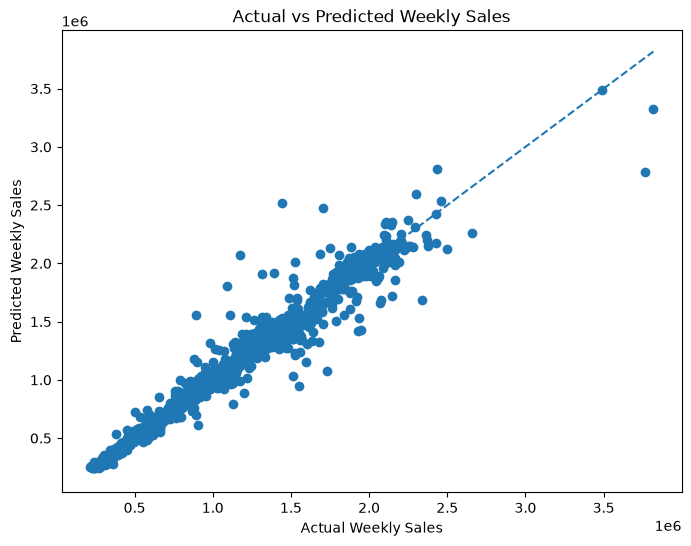

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_rf)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    linestyle="--"
)
plt.show()

After evaluating the models,we compare actual and predicted weekly sales.Points closer to the diagonal line indicate better predictions.This helps us visually assess the model performance.

Step 33- Cross Validation

In [53]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(rf_model,X,y,cv=5,scoring="r2")
print("Cross Validation Scores:",cv_scores)
print("Mean R2 Score:",cv_scores.mean())

Cross Validation Scores: [-0.17083979 -1.1999849  -0.87846832 -0.66966226 -1.06070618]
Mean R2 Score: -0.795932290506342


 5-fold cross-validation is used to check the stability of the Random Forest model.The model is evaluated on different validation folds.
The mean R² Score represents the average performance across all folds.A consistent R² Score indicates that the model performs reliably on different subsets of the training data.

Step 34 - Hyperparameter Tuning+ Tuned Model Evaluation

In [54]:
from sklearn.model_selection import GridSearchCV
param_grid={"n_estimators":[100,200],"max_depth":[10,15,None],"min_samples_split":[2,5]}
grid_search=GridSearchCV(RandomForestRegressor(random_state=42),param_grid,cv=3,scoring="r2",n_jobs=-1)
grid_search.fit(X_train,y_train)
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}



GridSearchCV is used to find suitable hyperparameters for Random Forest.
Different parameter combinations are evaluated using cross-validation.
The best configuration is used to make predictions on the test data.
The tuned model is evaluated using MAE, MSE, RMSE, and R² Score.

Step 35 - Final Model Comparision

In [ ]:
final_results=pd.concat([
    results,
    pd.DataFrame({
        "Model": ["Tuned Random Forest"],
        "MAE":[mae_tuned],
        "MSE":[mse_tuned],
        "RMSE":[rmse_tuned],
        "R2 Score":[r2_tuned]
    })
],ignore_index=True)
print("Final Model Comparison:")
print(final_results)

Final Model Comparison:
                 Model            MAE           MSE           RMSE  R2 Score
0    Linear Regression  433270.434227  2.723308e+11  521853.280452  0.154658
1        Decision Tree   73908.710681  2.009573e+10  141759.420368  0.937621
2        Random Forest   62106.928533  1.317054e+10  114762.971230  0.959117
3    Gradient Boosting  203330.206827  6.949744e+10  263623.676683  0.784273
4  Tuned Random Forest   61996.302958  1.280508e+10  113159.522807  0.960252



The tuned Random Forest results are added to the results of the previously trained models results. All models are compared using MAE, MSE, RMSE, and R² Score.This comparison helps identify the final best-performing model.

Step 36 - Final Best Model Selection

In [56]:
final_model=grid_search.best_estimator_
final_pred=final_model.predict(X_test)
final_mae=mean_absolute_error(y_test,final_pred)
final_mse=mean_squared_error(y_test,final_pred)
final_rmse=np.sqrt(final_mse)
final_r2=r2_score(y_test,final_pred)
print("Final Model MAE:",final_mae)
print("Final Model MSE:",final_mse)
print("Final Model RMSE:",final_rmse)
print("Final Model R2 Score:",final_r2)

Final Model MAE: 61996.30295797879
Final Model MSE: 12805077601.874414
Final Model RMSE: 113159.5228068518
Final Model R2 Score: 0.9602517579832126


All original and tuned models are compared based on their evaluation metrics.
The model with the highest R² Score is selected as the final best model.
This model is used for the final prediction on new unseen data.

Step 37 - New/Unseen Data Prediction

In [57]:
new_data=pd.DataFrame({
"Store":[np.random.randint(1,46)],
"Holiday_Flag":[np.random.randint(0,2)],
"Temperature":[np.random.uniform(40,90)],
"Fuel_Price":[np.random.uniform(2.5,4.5)],
"CPI":[np.random.uniform(125,225)],
"Unemployment":[np.random.uniform(4,12)],
"Year":[np.random.randint(2010,2013)],
"Month":[np.random.randint(1,13)],
"Week":[np.random.randint(1,53)],
"Quarter":[np.random.randint(1,5)]
})
prediction=final_model.predict(new_data)
new_data["Predicted_Weekly_Sales"]=prediction
print(new_data)

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0     17             1    89.997001    3.570859  141.642575     10.175751   

   Year  Month  Week  Quarter  Predicted_Weekly_Sales  
0  2010      8    30        3           786248.216408  


A new unseen input is provided to the final selected model.
The model predicts the expected Weekly Sales for the given store and conditions.
This demonstrates how the trained machine learning model can be used for future predictions.

Step 38 - Final Conclusion

In [ ]:
print("Machine Learning project completed successfully.")
print("Best Model:",best_model_name)
print("Predicted Weekly Sales:",prediction[0])

Machine Learning project completed successfully.
Best Model: Tuned Random Forest
Predicted Weekly Sales: 1445235.75576633


The Walmart sales dataset was successfully analyzed and preprocessed.
Important time-based features were created from the Date column.
Multiple regression models were trained and evaluated.
Cross-validation and hyperparameter tuning were applied to improve model reliability.
All models were compared using MAE, MSE, RMSE, and R² Score.
The best-performing model was selected based on the evaluation results.
Finally, the selected model was used to predict Weekly Sales for new unseen data.